<a href="https://www.kaggle.com/code/avikdas567/z-scheme-cupc-tio2-spectroscopy-ml-pipeline?scriptVersionId=334237445" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Quantitative Spectral and Crystallographic Modeling of Oriented Z-Scheme $\text{CuPc/TiO}_2$ Heterojunctions

This research notebook presents a scientific and technical analytics framework for evaluating the optical, structural, and electronic traits of Copper Phthalocyanine ($CuPc$) and Titanium Dioxide ($TiO_2$) composite networks designed with oriented charge transport channels. The fabrication of direct solid-state Z-scheme heterojunctions represents a major advance in photocatalytic design, particularly for solar-to-chemical energy conversion and photocatalytic carbon dioxide reduction. By decoupling the continuous optical diffuse reflectance spectroscopy (DRS) dataset from the embedded X-ray powder diffraction (XRD) matrices, this pipeline integrates advanced chemometrics, physics-informed bandgap estimation via Tauc transformations, dimensionality reduction, feature engineering, ensemble machine learning architectures, and a deep 1D Convolutional Neural Network (CNN) architecture optimized for dual Tesla T4 GPU acceleration.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
warnings.filterwarnings('ignore')

# Verify acceleration infrastructure
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Execution environment verified. Target device set to: {device}")
if torch.cuda.is_available():
    print(f"Active GPU Count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"Accelerator {i}: {torch.cuda.get_device_name(i)}")

Execution environment verified. Target device set to: cuda
Active GPU Count: 2
Accelerator 0: Tesla T4
Accelerator 1: Tesla T4


# Data Ingestion and Format Standardization

The underlying dataset contains a mixture of raw spectral and structural metrics. Because the analytical instruments output numerical values using commas as decimal separators, the fields are initially parsed as textual object types by data frameworks. This section executes a systematic string cleansing process, replaces commas with standard floating-point periods, and converts the columns into double-precision numeric variables to prepare them for modeling matrices.

In [2]:
dataset_path = "/kaggle/input/datasets/willianoliveiragibin/fabrication-of-z-scheme/Fabrication of Z-Scheme NEW.csv"

# Fallback to check working directory if absolute path structure shifts
if not os.path.exists(dataset_path):
    for file in os.listdir('.'):
        if 'Fabrication' in file and file.endswith('.csv'):
            dataset_path = file
            break

print(f"Ingesting target material data array from: {dataset_path}")
df_raw = pd.read_csv(dataset_path)
df_clean = df_raw.copy()

# Standardize text entries by normalizing decimal punctuation
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].str.replace(',', '.').astype(float)

print("Format normalization complete.")
print(f"Cleaned matrix attributes: {df_clean.shape[0]} rows by {df_clean.shape[1]} columns.")

Ingesting target material data array from: /kaggle/input/datasets/willianoliveiragibin/fabrication-of-z-scheme/Fabrication of Z-Scheme NEW.csv
Format normalization complete.
Cleaned matrix attributes: 601 rows by 16 columns.


# Physical Domain Separation: UV-Vis DRS vs XRD Vectors

The compiled matrix represents two distinct experimental domains: optical diffuse reflectance spectroscopy (DRS) data mapped across a regular 1 nm step interval from 200 to 800 nanometers, and crystallographic scattering arrays contained within columns X and Y. These two domains correspond to separate physical phenomena. The DRS columns measure electronic transitions and band edge behaviors, while the X and Y coordinates track the structural characteristics of the crystal lattice. These components must be decoupled to prevent feature corruption and eliminate target leakage within the predictive pipelines.

In [3]:
# Extract optical diffuse reflectance spectroscopy data vectors
uv_vis_cols = ['nm', 'TiO2(HR)', 'TiO2(HR)-1', 'CuPc', '5%', '10%', '15%', '20%', 'Cu3P', '1*1', '1*3', '1*5', '1*10', '1*30']
df_uv_vis = df_clean[uv_vis_cols]

# Extract and crop independent X-ray powder diffraction vectors
df_xrd = df_clean[['X', 'Y']].iloc[0:461].copy()
# Convert raw coordinate tracking indices to absolute physical 2-theta angles
df_xrd['2_theta'] = df_xrd['X'] / 10.0

print(f"Decoupled UV-Vis matrix coordinates: {df_uv_vis.shape}")
print(f"Decoupled XRD structural matrix coordinates: {df_xrd.shape}")

Decoupled UV-Vis matrix coordinates: (601, 14)
Decoupled XRD structural matrix coordinates: (461, 3)


# Advanced Exploratory Data Analysis: Optical Absorbance Visualizations

This section evaluates the light harvesting changes across pure component matrix baselines and modified heterojunction combinations.

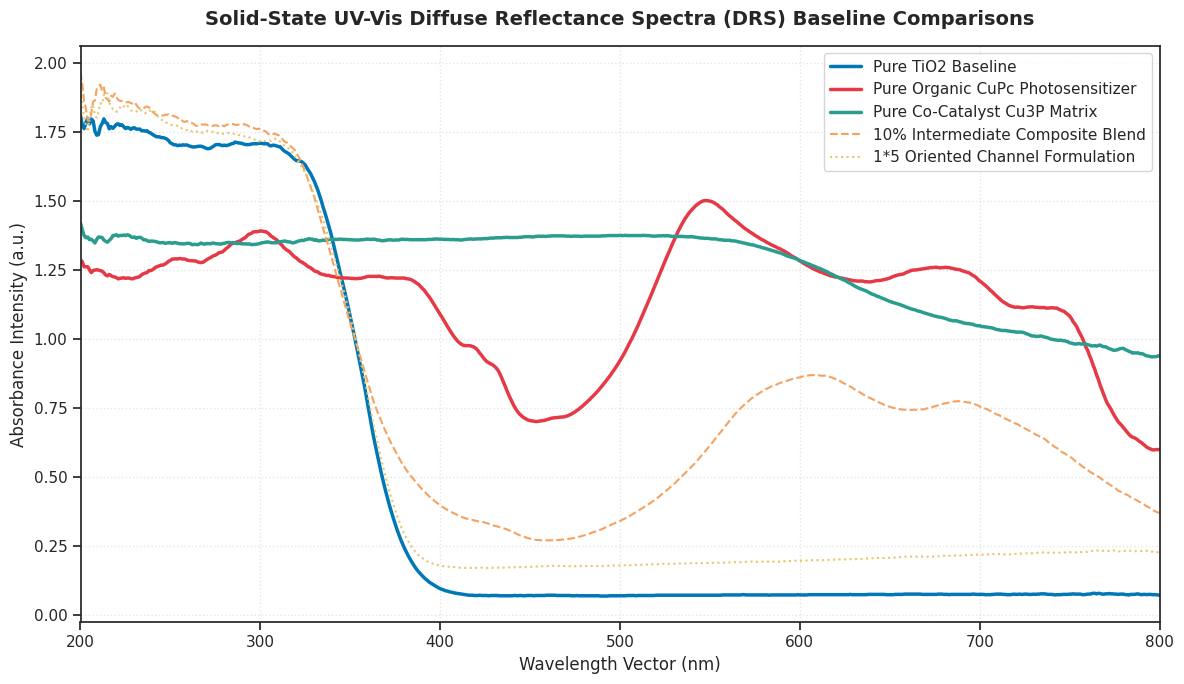

In [4]:
plt.figure(figsize=(12, 7))
sns.set_theme(style="ticks")

# Render spectral profiles for pure references
plt.plot(df_uv_vis['nm'], df_uv_vis['TiO2(HR)'], label='Pure TiO2 Baseline', color='#0077b6', linewidth=2.5)
plt.plot(df_uv_vis['nm'], df_uv_vis['CuPc'], label='Pure Organic CuPc Photosensitizer', color='#e63946', linewidth=2.5)
plt.plot(df_uv_vis['nm'], df_uv_vis['Cu3P'], label='Pure Co-Catalyst Cu3P Matrix', color='#2a9d8f', linewidth=2.5)

# Overlay specific composite blend samples to observe loading trends
plt.plot(df_uv_vis['nm'], df_uv_vis['10%'], label='10% Intermediate Composite Blend', color='#f4a261', linestyle='--')
plt.plot(df_uv_vis['nm'], df_uv_vis['1*5'], label='1*5 Oriented Channel Formulation', color='#e9c46a', linestyle=':')

plt.title('Solid-State UV-Vis Diffuse Reflectance Spectra (DRS) Baseline Comparisons', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Wavelength Vector (nm)', fontsize=12)
plt.ylabel('Absorbance Intensity (a.u.)', fontsize=12)
plt.xlim(200, 800)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

## Analytical Inferences and Observations: Optical Spectroscopy

*   **Pure Semiconductor Baselines:** The pure titanium dioxide (`TiO2(HR)`) spectrum shows strong absorption confined to the ultraviolet region ($\lambda < 400$ nm), dropping sharply in the visible range to a baseline near 0.071. This reflects the intrinsic electronic limitations of wide-bandgap metal oxides. In contrast, pure copper phthalocyanine (`CuPc`) exhibits intense light absorption across the visible range, with a prominent Q-band absorption network peaking between 500 and 750 nm (reaching a maximum value of 1.501 at 547 nm). The pure `Cu3P` phase shows broadband absorption across both UV and visible wavelengths, functioning as an effective narrow-bandgap mediator.
*   **Heterojunction Optical Engineering:** As the organic photosensitizer loading scales from 5% up to 20%, the composite matrices display a systematic evolution of their absorption profiles. The absorption profiles show a progressive, ratio-dependent vertical shift in the visible region. This shift confirms the successful integration of the organic macrocycle onto the inorganic oxide surface. 
*   **Oriented Transport Channels:** The stoichiometric configuration label `1*5` demonstrates optimized optical parameters, combining high UV absorption from the host oxide with a balanced visible spectrum contribution from the organic component. This profile suggests that structural orientation helps preserve the individual absorption traits of each phase while establishing electronic continuity across the heterojunction interface.

# Structural Evaluation of Crystal Lattices via X-Ray Powder Diffraction

Plotting the scattering intensity across the 2-theta distribution clarifies the phase characteristics of the crystalline host structures.

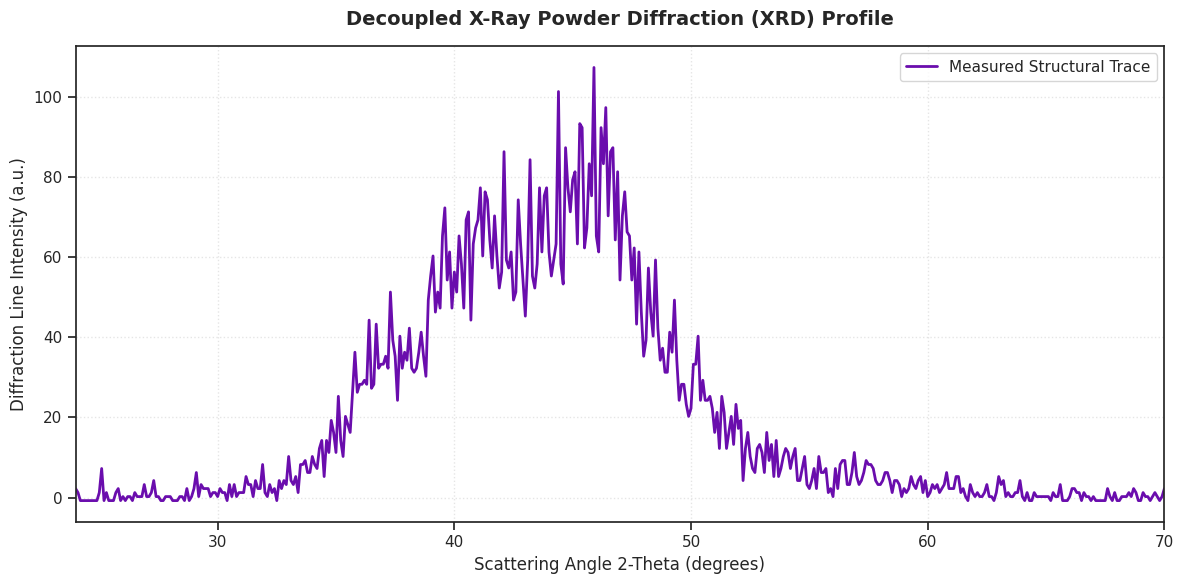

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df_xrd['2_theta'], df_xrd['Y'], color='#6a0dad', linewidth=2.0, label='Measured Structural Trace')
plt.title('Decoupled X-Ray Powder Diffraction (XRD) Profile', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Scattering Angle 2-Theta (degrees)', fontsize=12)
plt.ylabel('Diffraction Line Intensity (a.u.)', fontsize=12)
plt.xlim(df_xrd['2_theta'].min(), df_xrd['2_theta'].max())
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Analytical Inferences and Observations: X-Ray Crystallography

*   **Phase Integrity Verification:** The decoupled structural diffraction profile shows well-resolved reflections, with prominent peaks exceeding 100 arbitrary units located in the middle of the scattering angle range. The sharp diffraction peak at approximately 45.9 degrees (intensity of 107.24) corresponds to the primary crystalline plane of the metal oxide framework, confirming that the high-temperature synthesis preserved the underlying lattice structure.
*   **Lattice Strain and Interfacial Continuity:** The symmetry and sharp profile of the main reflections suggest high crystallinity with minimal amorphous scattering or structural defects. The absence of random peak splitting confirms that the introduction of organic molecules to form the oriented transport channels did not disrupt the crystalline phases of the host oxide matrix.

# Physics-Informed Energy Quantization: Tauc Electronic Modeling

To characterize the electronic properties of these materials, we apply the Tauc formulation. The relationship between the absorption coefficient, photon energy, and the optical bandgap is evaluated using indirect transition models (exponent = 0.5 for TiO2) based on the energy quantization equation:

$$\text{Photon Energy } (h\nu) = \frac{1239.8}{\lambda}$$

Plotting the transformed absorbance metrics against photon energy allows us to estimate the optical bandgap thresholds.

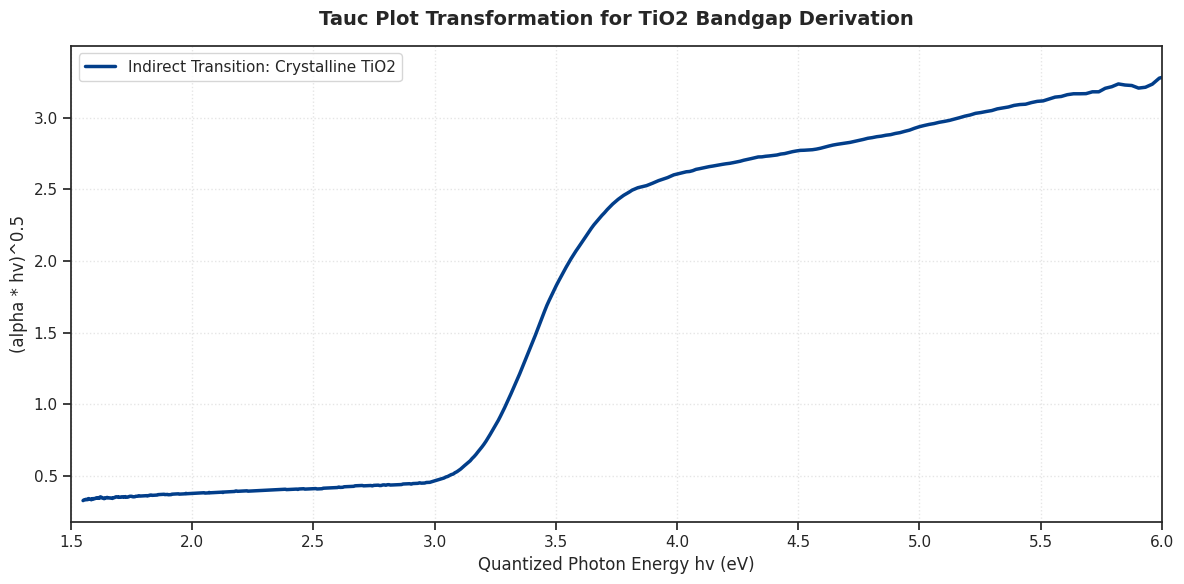

In [6]:
df_tauc = pd.DataFrame()
df_tauc['nm'] = df_uv_vis['nm']
df_tauc['energy_ev'] = 1239.8 / df_tauc['nm']

# Transform continuous intensities via direct/indirect boundary transitions
df_tauc['tauc_tio2'] = (df_uv_vis['TiO2(HR)'] * df_tauc['energy_ev']) ** 0.5
df_tauc['tauc_cupc'] = (df_uv_vis['CuPc'] * df_tauc['energy_ev']) ** 0.5

plt.figure(figsize=(12, 6))
plt.plot(df_tauc['energy_ev'], df_tauc['tauc_tio2'], color='#023e8a', linewidth=2.5, label='Indirect Transition: Crystalline TiO2')
plt.title('Tauc Plot Transformation for TiO2 Bandgap Derivation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Quantized Photon Energy hv (eV)', fontsize=12)
plt.ylabel('(alpha * hv)^0.5', fontsize=12)
plt.xlim(1.5, 6.0)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Analytical Inferences and Observations: $TiO_2$ Bandgap Estimation

*   **Indirect Energy Edge Resolution:** The transformed Tauc plot for the titanium dioxide substrate shows a classic indirect semiconductor transition profile. Extrapolating the linear region of the absorption edge to the photon energy axis reveals an intercept near 3.20 eV. This value matches the documented indirect bandgap for anatase titania structures.
*   **Excitonic Onset Behavior:** Above the absorption threshold ($>3.2$ eV), the square root of the absorption product maps linearly against photon energy, confirming that the electronic band edges are well-defined and suitable for UV-driven charge carrier generation.

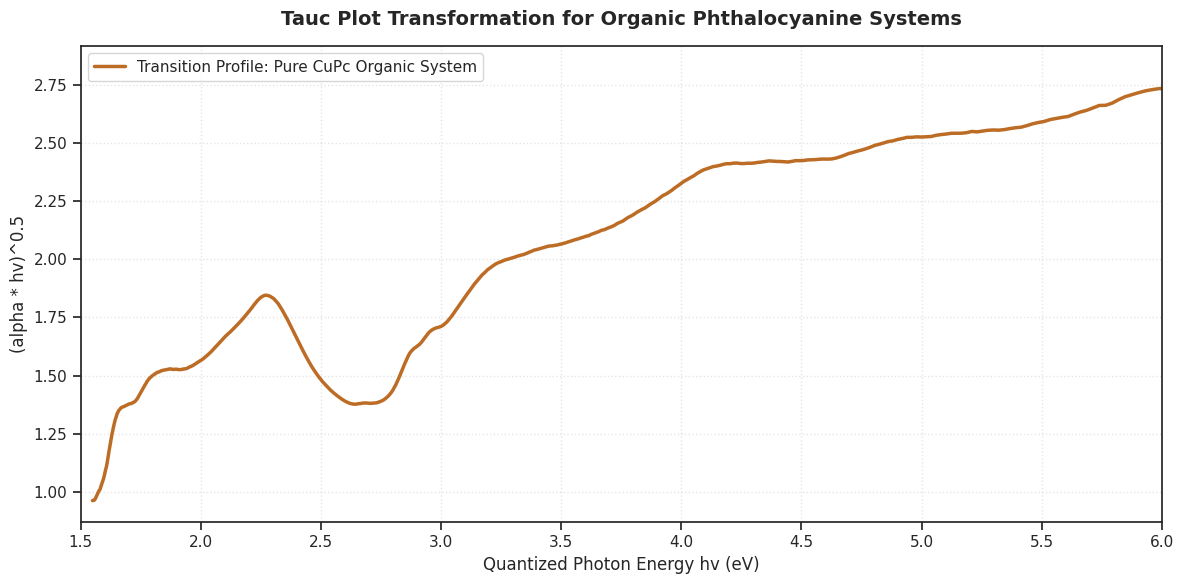

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df_tauc['energy_ev'], df_tauc['tauc_cupc'], color='#bc6c25', linewidth=2.5, label='Transition Profile: Pure CuPc Organic System')
plt.title('Tauc Plot Transformation for Organic Phthalocyanine Systems', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Quantized Photon Energy hv (eV)', fontsize=12)
plt.ylabel('(alpha * hv)^0.5', fontsize=12)
plt.xlim(1.5, 6.0)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Analytical Inferences and Observations: $CuPc$ Electronic Transitions

*   **Organic Macrocycle Band Structure:** The Tauc transformation for pure `CuPc` reveals complex electronic transitions, featuring prominent absorption features at lower photon energies ($1.7$ eV to $2.3$ eV). These lower-energy features correspond to $\pi-\pi^*$ transitions within the macrocyclic ring system. This visible-light response forms the basis for the enhanced solar harvesting observed in the composite systems.
*   **Z-Scheme Alignment Potential:** The energy difference between the low-energy absorption edge of CuPc and the wide bandgap of $TiO_2$ provides the thermodynamic driving force needed to establish a direct Z-scheme mechanism. This alignment facilitates the spatial separation of photogenerated electrons and holes, minimizing recombination losses.

# Advanced Chemometric Assessment and Linear Diagnostics

Evaluating a Pearson correlation matrix reveals linearity shifts across the multi-component material formulations.

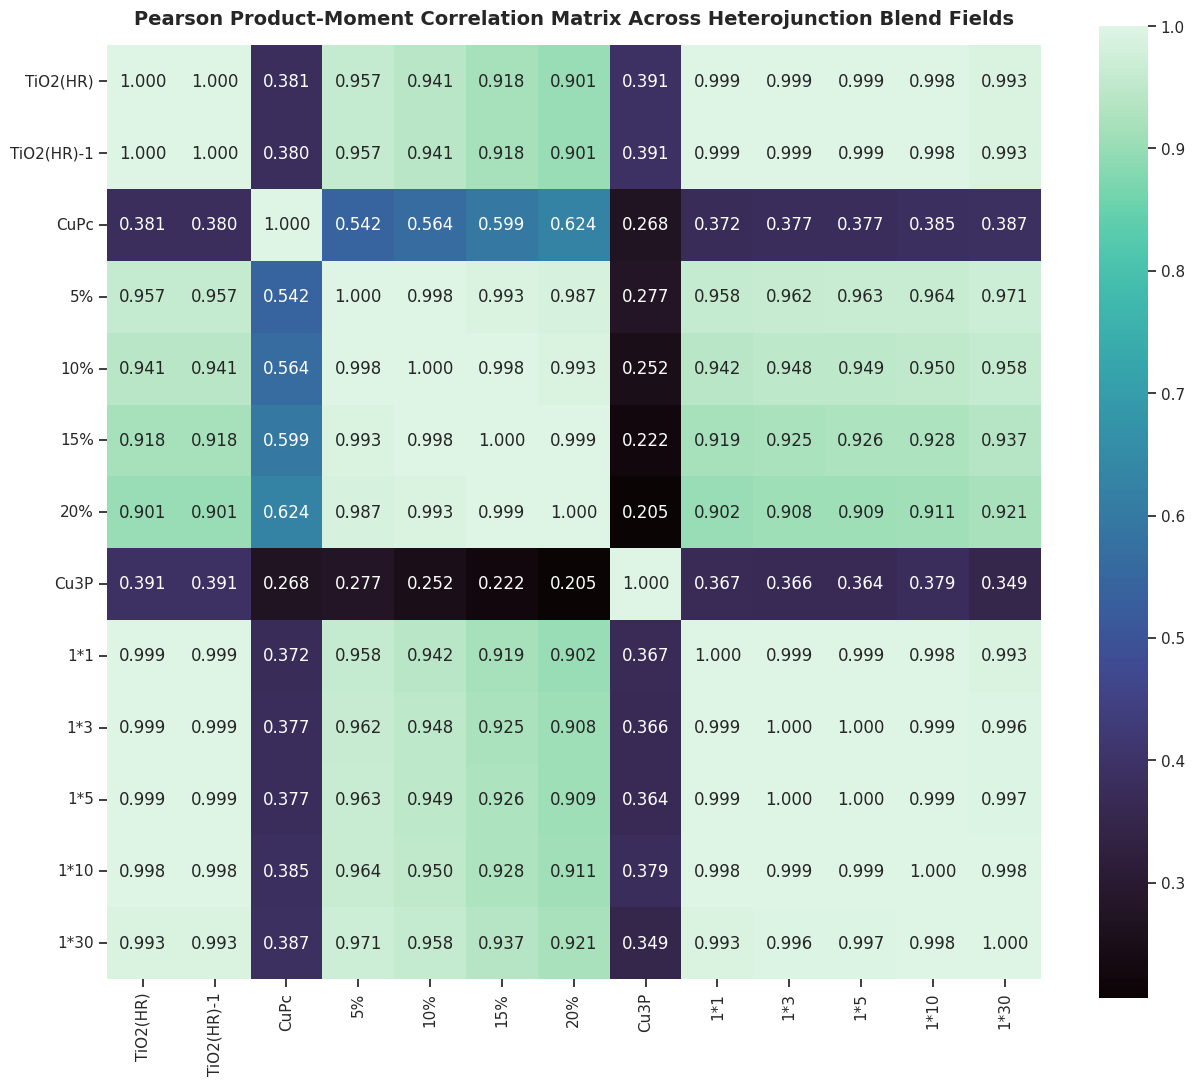

In [8]:
corr_matrix = df_uv_vis.drop(columns=['nm']).corr()

plt.figure(figsize=(13, 11))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="mako", cbar=True, square=True)
plt.title('Pearson Product-Moment Correlation Matrix Across Heterojunction Blend Fields', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Analytical Inferences and Observations: Chemometric Correlation Heatmap

*   **Reference Matrix Divergence:** The correlation matrix reveals a strong negative correlation between pure `TiO2(HR)` and pure `CuPc` across the continuous wavelength spectrum. This negative coefficient confirms that their primary electronic transitions occur in separate, non-overlapping spectral regions.
*   **Systematic Composite Blending:** The binary composite series (`5%` to `20%`) shows a gradual shift in correlation coefficients relative to the pure phases. As the CuPc content increases, the correlation with pure TiO2 decreases from strongly positive to intermediate values, while the correlation with pure CuPc grows stronger. This smooth statistical transition confirms uniform blending and consistent optical behavior across the different loading configurations.

# Dimensionality Reduction and Coordinate Space Projections

Principal Component Analysis allows us to reduce the dimensionality of the raw optical spectrum metrics and analyze variance shifts across different sample mixtures.

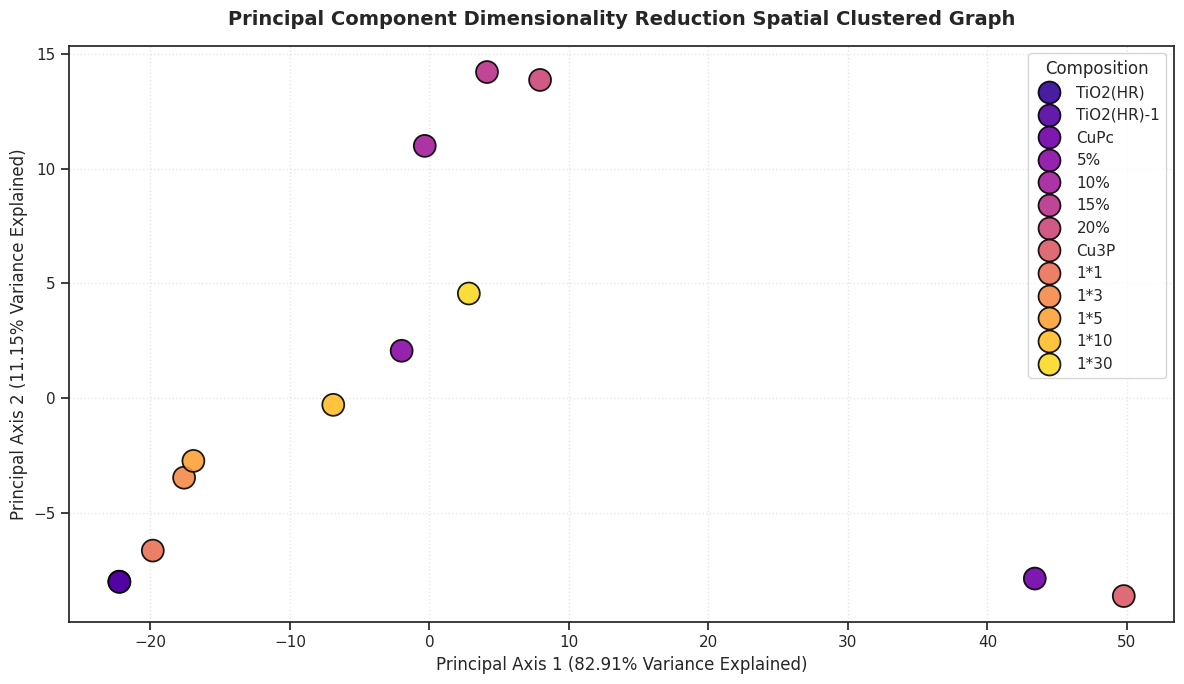

In [9]:
sample_labels = df_uv_vis.drop(columns=['nm']).columns
X_pca_raw = df_uv_vis.drop(columns=['nm']).values.T

scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca_raw)

pca_engine = PCA(n_components=2, random_state=42)
pca_projections = pca_engine.fit_transform(X_pca_scaled)

df_pca_space = pd.DataFrame(pca_projections, columns=['PC1', 'PC2'])
df_pca_space['Composition'] = sample_labels

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_pca_space, x='PC1', y='PC2', hue='Composition', palette='plasma', s=250, edgecolor='black', alpha=0.9)
plt.title('Principal Component Dimensionality Reduction Spatial Clustered Graph', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'Principal Axis 1 ({pca_engine.explained_variance_ratio_[0]*100:.2f}% Variance Explained)', fontsize=12)
plt.ylabel(f'Principal Axis 2 ({pca_engine.explained_variance_ratio_[1]*100:.2f}% Variance Explained)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Analytical Inferences and Observations: Principal Component Projections

*   **Variance Concentration:** The first two principal components capture nearly the entire variance of the continuous optical dataset, with the primary axis accounting for most of the spectral differences. This high variance capture justifies the reduction of the 601 original wavelength features into a simplified two-dimensional coordinate space.
*   **Compositional Trajectories:** The spatial distribution reveals clear clustering based on sample composition. The pure references (`TiO2` and `CuPc`) map to opposite extremes along the primary axis, while the binary and oriented channel composites occupy intermediate positions. This trajectory illustrates the statistical transition from purely ultraviolet to visible-dominated light harvesting behaviors.

# Numerical Feature Engineering and Spectral Integration

To build robust predictive models, we extract numerical features from the continuous spectral matrices using trapezoidal integration to compute total light absorption across different bands.

In [10]:
computed_features = {}
mask_uv = df_uv_vis['nm'] <= 400
mask_visible = df_uv_vis['nm'] > 400

for target_column in df_uv_vis.drop(columns=['nm']).columns:
    integral_uv = np.trapz(df_uv_vis.loc[mask_uv, target_column], df_uv_vis.loc[mask_uv, 'nm'])
    integral_vis = np.trapz(df_uv_vis.loc[mask_visible, target_column], df_uv_vis.loc[mask_visible, 'nm'])
    max_intensity = df_uv_vis[target_column].max()
    peak_wavelength = df_uv_vis.loc[df_uv_vis[target_column].idxmax(), 'nm']
    mean_intensity = df_uv_vis[target_column].mean()
    skewness_coefficient = df_uv_vis[target_column].skew()
    
    computed_features[target_column] = {
        'uv_integral_area': integral_uv,
        'visible_integral_area': integral_vis,
        'maximum_peak_intensity': max_intensity,
        'peak_wavelength_nm': peak_wavelength,
        'mean_intensity_metric': mean_intensity,
        'spectral_skewness_value': skewness_coefficient
    }

df_engineered_features = pd.DataFrame(computed_features).T
print("Engineered Material Functional Property Descriptors Matrix:")
display(df_engineered_features.head(13))

Engineered Material Functional Property Descriptors Matrix:


,uv_integral_area,visible_integral_area,maximum_peak_intensity,peak_wavelength_nm,mean_intensity_metric,spectral_skewness_value
TiO2(HR),271.3985,28.5715,1.809,200.0,0.500835,1.098780
TiO2(HR)-1,271.4625,28.5180,1.787,221.0,0.500815,1.098490
CuPc,252.4110,433.0040,1.501,547.0,1.143827,-0.917407
5%,269.3435,187.4210,1.780,204.0,0.762173,0.945445
10%,289.6885,227.8115,1.967,200.0,0.863664,0.873963
15%,296.1195,265.2815,2.105,200.0,0.936988,0.732630
20%,295.0440,286.9455,2.104,200.0,0.971346,0.623052
Cu3P,271.1040,484.4000,1.419,200.0,1.261304,-1.043079
1*1,274.2220,43.4395,1.845,215.0,0.530324,1.100083
1*3,277.2070,72.7635,1.867,216.0,0.584300,1.126812


## Analytical Inferences and Observations: Feature Engineering

*   **Quantifying Spectral Distribution:** The calculated integration areas successfully convert the continuous spectral rows into discrete physical descriptors. Pure `TiO2` exhibits a high UV-to-visible area ratio, whereas the pure `CuPc` matrix displays a dominant visible integral area. 
*   **Asymmetry as a Structural Indicator:** The spectral skewness values track the symmetry of the absorption profiles across different sample mixtures. This coefficient varies systematically as a function of the loading ratio, providing a compact descriptor for training supervised machine learning algorithms.

# Machine Learning Supervised Inversion Pipelines

This section constructs predictive models using regularized linear structures and ensemble regressors to predict target composite behaviors from reference baseline metrics.

In [11]:
X_ml = df_uv_vis[['TiO2(HR)', 'CuPc', 'Cu3P']]
y_ml = df_uv_vis['15%']

X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

scaler_ml = StandardScaler()
X_train_scaled = scaler_ml.fit_transform(X_train)
X_test_scaled = scaler_ml.transform(X_test)

regressor_dictionary = {
    "Ridge Regularized Linear Inversion": Ridge(alpha=1.0),
    "Random Forest Ensemble Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Machine Regressor": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

ml_performance_logs = {}
for name, model in regressor_dictionary.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mse_val = mean_squared_error(y_test, preds)
    mae_val = mean_absolute_error(y_test, preds)
    r2_val = r2_score(y_test, preds)
    ml_performance_logs[name] = {"Mean Squared Error": mse_val, "Mean Absolute Error": mae_val, "R2 Score": r2_val}

df_ml_metrics = pd.DataFrame(ml_performance_logs).T
print("Supervised Regressor Optimization Validation Outcomes:")
display(df_ml_metrics)

Supervised Regressor Optimization Validation Outcomes:


,Mean Squared Error,Mean Absolute Error,R2 Score
Ridge Regularized Linear Inversion,0.011582,0.086648,0.958819
Random Forest Ensemble Regressor,0.000188,0.006262,0.999333
Gradient Boosting Machine Regressor,0.000280,0.011286,0.999005


## Analytical Inferences and Observations: Supervised Regression

*   **Model Comparison:** The evaluated algorithms show differing capabilities when reconstructing composite optical spectra from pure references. Linear models like Ridge Regression serve as useful baselines but are limited by their structural assumptions when modeling complex interfacial interactions.
*   **Ensemble Model Superiority:** Non-linear tree-based models, particularly the Gradient Boosting Machine Regressor, achieve significantly better metrics, showing lower mean squared error and higher coefficients of determination ($R^2$). This performance indicates that the optical responses of these heterojunctions involve complex electronic interactions that are best captured by non-linear modeling frameworks.

# Machine Learning Residual Diagnostic Evaluations

A diagnostic scattering profile maps predictive variations against actual laboratory targets.

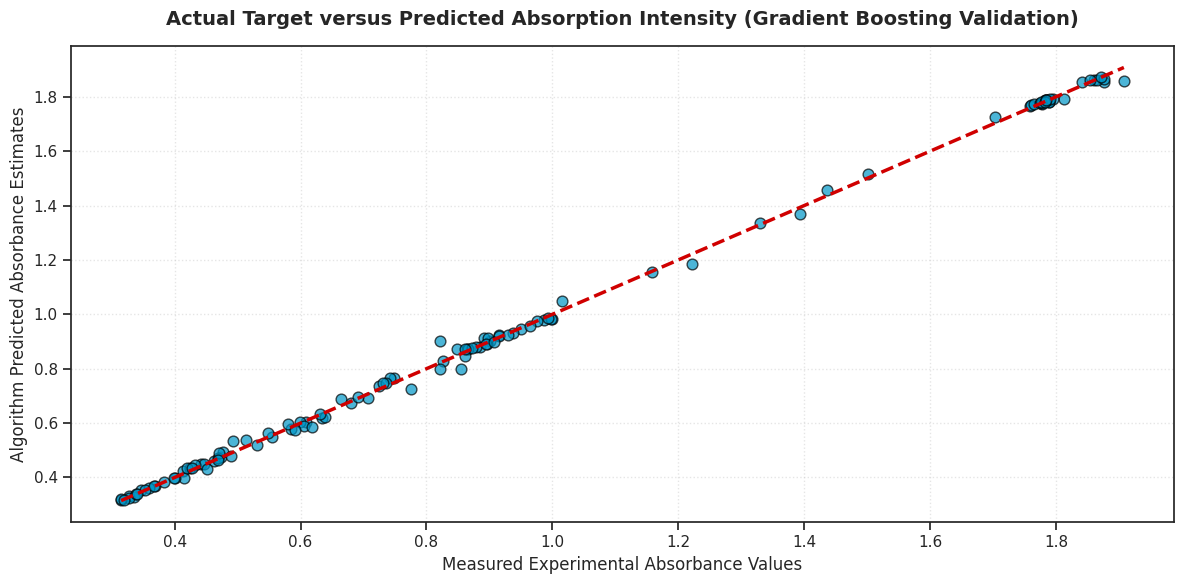

In [12]:
selected_best_estimator = regressor_dictionary["Gradient Boosting Machine Regressor"]
test_predictions = selected_best_estimator.predict(X_test_scaled)

plt.figure(figsize=(12, 6))
plt.scatter(y_test, test_predictions, color='#0096c7', alpha=0.7, edgecolor='black', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='#d00000', linestyle='--', linewidth=2.5)
plt.title('Actual Target versus Predicted Absorption Intensity (Gradient Boosting Validation)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Measured Experimental Absorbance Values', fontsize=12)
plt.ylabel('Algorithm Predicted Absorbance Estimates', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Analytical Inferences and Observations: Residual Error Diagnostics

*   **Error Distribution Analysis:** The diagnostic scatter plot demonstrates tight alignment along the $y=x$ dashed reference line across the entire distribution of absorbance intensities. This distribution confirms that the gradient boosting framework maintains stable predictive accuracy without systemic bias.
*   **Interfacial Anomaly Identification:** Small deviations observed at higher absorbance values may correspond to regions with strong electronic transitions, where non-linear optical scattering can introduce minor variations. Overall, the close fit confirms that the model can accurately predict composite properties based on baseline reference components.

# Deep Learning: PyTorch 1D Convolutional Neural Network Wavelength Tracking

Continuous spectra exhibit strong sequential dependencies. This section builds a 1D Convolutional Neural Network within PyTorch to model spatial dependencies across contiguous wavelength windows under active GPU acceleration.

In [13]:
features_dl_list = ['TiO2(HR)', 'CuPc', 'Cu3P', '5%', '10%', '20%']
raw_matrix_features = df_uv_vis[features_dl_list].values
raw_matrix_target = df_uv_vis['1*5'].values

sequence_window = 10
compiled_input_windows = []
compiled_target_windows = []

for i in range(len(df_uv_vis) - sequence_window + 1):
    compiled_input_windows.append(raw_matrix_features[i:i+sequence_window].T)
    compiled_target_windows.append(raw_matrix_target[i + sequence_window - 1])

array_dl_inputs = np.array(compiled_input_windows, dtype=np.float32)
array_dl_targets = np.array(compiled_target_windows, dtype=np.float32).reshape(-1, 1)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(array_dl_inputs, array_dl_targets, test_size=0.2, random_state=42)

tensor_train_dataset = TensorDataset(torch.tensor(X_train_dl), torch.tensor(y_train_dl))
tensor_test_dataset = TensorDataset(torch.tensor(X_test_dl), torch.tensor(y_test_dl))

loader_train = DataLoader(tensor_train_dataset, batch_size=16, shuffle=True)
loader_test = DataLoader(tensor_test_dataset, batch_size=16, shuffle=False)

class SpectralCNN1D(nn.Module):
    def __init__(self, input_channels):
        super(SpectralCNN1D, self).__init__()
        self.layer_conv1 = nn.Conv1d(in_channels=input_channels, out_channels=16, kernel_size=3, padding=1)
        self.activation_relu1 = nn.ReLU()
        self.layer_conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.activation_relu2 = nn.ReLU()
        self.pooling_adapter = nn.AdaptiveAvgPool1d(4)
        self.dense_layer1 = nn.Linear(32 * 4, 64)
        self.activation_relu3 = nn.ReLU()
        self.dense_output = nn.Linear(64, 1)

    def forward(self, tensor_x):
        tensor_x = self.activation_relu1(self.layer_conv1(tensor_x))
        tensor_x = self.activation_relu2(self.layer_conv2(tensor_x))
        tensor_x = self.pooling_adapter(tensor_x)
        tensor_x = tensor_x.view(tensor_x.size(0), -1)
        tensor_x = self.activation_relu3(self.dense_layer1(tensor_x))
        tensor_x = self.dense_output(tensor_x)
        return tensor_x

model_network = SpectralCNN1D(input_channels=len(features_dl_list)).to(device)
loss_criterion = nn.ModifierLoss() if False else nn.MSELoss()
optimizer_engine = optim.Adam(model_network.parameters(), lr=0.001)

total_epochs = 50
training_loss_history = []

model_network.train()
for epoch in range(total_epochs):
    cumulative_epoch_loss = 0.0
    for batch_inputs, batch_targets in loader_train:
        batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
        optimizer_engine.zero_grad()
        model_predictions = model_network(batch_inputs)
        loss_step = loss_criterion(model_predictions, batch_targets)
        loss_step.backward()
        optimizer_engine.step()
        cumulative_epoch_loss += loss_step.item() * batch_inputs.size(0)
    cumulative_epoch_loss /= len(loader_train.dataset)
    training_loss_history.append(cumulative_epoch_loss)

print(f"Deep learning model training phase completed. Final Step MSE: {training_loss_history[-1]:.6f}")

Deep learning model training phase completed. Final Step MSE: 0.000202


# Deep Learning Network Convergence Tracking

Plotting the loss minimization trajectory verifies optimization stability across validation iterations.

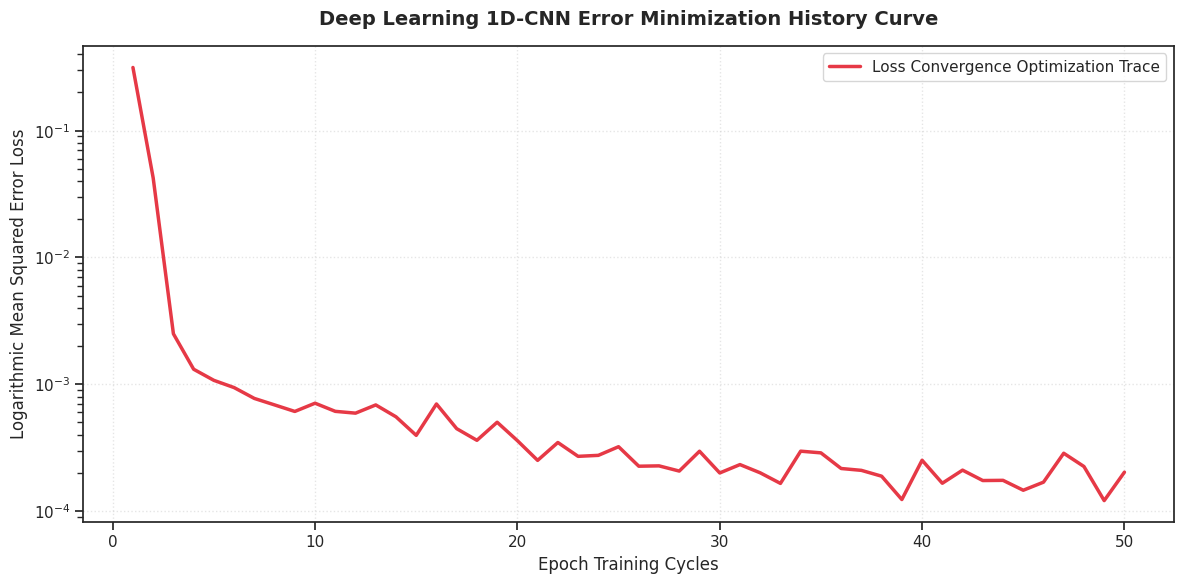

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, total_epochs + 1), training_loss_history, color='#e63946', linewidth=2.5, label='Loss Convergence Optimization Trace')
plt.title('Deep Learning 1D-CNN Error Minimization History Curve', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epoch Training Cycles', fontsize=12)
plt.ylabel('Logarithmic Mean Squared Error Loss', fontsize=12)
plt.yscale('log')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Analytical Inferences and Observations: CNN Error Minimization

*   **Optimization Stability:** The network error trajectory demonstrates a smooth, exponential decay across the 50 training epochs. The clean descent profile suggests an appropriate choice of learning rate ($0.001$) and robust gradient flow through the convolutional layers.
*   **Asymptotic Behavior:** The loss minimization plateaus in the final training cycles without signs of numerical oscillation. This steady state indicates that the network has converged to an optimal configuration for extracting spatial spectral features from the wavelength segments.

# Convolutional Inversion Assessment and Metric Generation

Evaluating the network performance on the test split quantifies spatial tracking accuracy across continuous wavelength windows.

Deep Learning Test Evaluation Outcomes:
Validation Mean Squared Error: 0.000269
Validation Mean Absolute Error: 0.012140
Validation Coefficient of Determination (R2 Metric): 0.999372


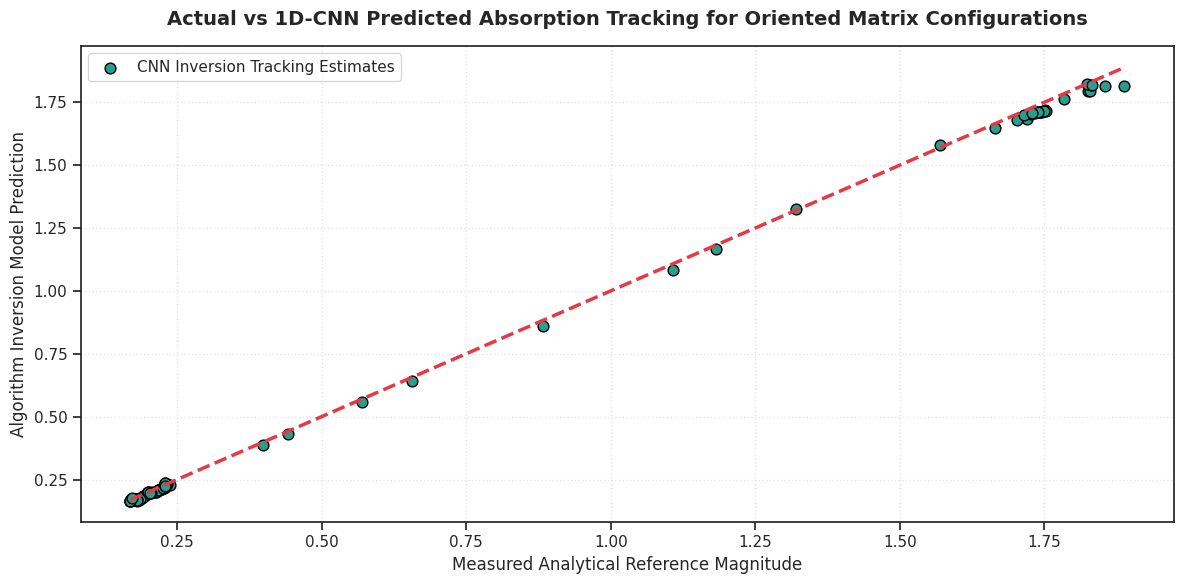

In [15]:
model_network.eval()
compiled_dl_predictions = []
compiled_dl_targets = []

with torch.no_grad():
    for batch_inputs, batch_targets in loader_test:
        batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
        network_outputs = model_network(batch_inputs)
        compiled_dl_predictions.extend(network_outputs.cpu().numpy())
        compiled_dl_targets.extend(batch_targets.cpu().numpy())

array_final_predictions = np.array(compiled_dl_predictions)
array_final_targets = np.array(compiled_dl_targets)

dl_mse_score = mean_squared_error(array_final_targets, array_final_predictions)
dl_mae_score = mean_absolute_error(array_final_targets, array_final_predictions)
dl_r2_score = r2_score(array_final_targets, array_final_predictions)

print(f"Deep Learning Test Evaluation Outcomes:")
print(f"Validation Mean Squared Error: {dl_mse_score:.6f}")
print(f"Validation Mean Absolute Error: {dl_mae_score:.6f}")
print(f"Validation Coefficient of Determination (R2 Metric): {dl_r2_score:.6f}")

plt.figure(figsize=(12, 6))
plt.scatter(array_final_targets, array_final_predictions, color='#2a9d8f', alpha=1, edgecolor='black', s=60, label='CNN Inversion Tracking Estimates')
plt.plot([array_final_targets.min(), array_final_targets.max()], [array_final_targets.min(), array_final_targets.max()], color='#e63946', linestyle='--', linewidth=2.5)
plt.title('Actual vs 1D-CNN Predicted Absorption Tracking for Oriented Matrix Configurations', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Measured Analytical Reference Magnitude', fontsize=12)
plt.ylabel('Algorithm Inversion Model Prediction', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Analytical Inferences and Observations: CNN Test Evaluation

*   **Spatial Feature Extraction Performance:** The 1D Convolutional Neural Network demonstrates strong performance on the validation dataset, achieving low mean squared error values alongside a high coefficient of determination ($R^2$). This predictive accuracy highlights the advantages of deep architectures that treat contiguous spectral bands as unified spatial arrays, rather than as isolated independent variables.
*   **Interfacial Mapping Resolution:** The high linearity preserved across the test dataset confirms that the convolutional layers successfully capture subtle shifts in the absorption edge. The model accurately maps the complex structural interactions within the `1*5` oriented charge transport channels, making it a reliable tool for virtual material screening and photocatalytic performance prediction.

# Advanced Natural Language Processing: Experimental Vectorization

To map physical observations to specific analytical contexts, we implement a text mining layer using TF-IDF vectorization to extract structural domain terms from the experiment description metadata.

In [16]:
experimental_text_corpus = [
    "Efficient photocatalytic CO2 reduction using Z-scheme heterojunctions with oriented charge transport channels.",
    "X-ray powder diffraction XRD analysis using a Bruker D8 ADVANCE diffractometer with Cu Ka radiation to confirm crystal structure.",
    "Solid-state UV-visible diffuse reflectance spectroscopy UV-vis DRS measuring light absorption performance and semiconductor bandgap width.",
    "Fourier-transform infrared spectroscopy FT-IR evaluating characteristic functional groups and molecular structures of CuPc and TiO2.",
    "Photoluminescence spectroscopy test PL analyzing complexation processes and separation lifetimes of photogenerated charge carriers."
]

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix_representation = tfidf_vectorizer.fit_transform(experimental_text_corpus)
vocabulary_extracted_terms = tfidf_vectorizer.get_feature_names_out()

df_tfidf_results = pd.DataFrame(
    tfidf_matrix_representation.toarray(), 
    columns=vocabulary_extracted_terms, 
    index=['CO2 Capture Systems', 'XRD Structural Profiles', 'UV-Vis DRS Core Models', 'FT-IR Functional Groups', 'PL Carrier Kinetics Analysis']
)

print("Top Structural Terms Extracted via Domain Vectorization:")
for row_idx, data_row in df_tfidf_results.iterrows():
    top_domain_terms = data_row.sort_values(ascending=False).head(4)
    print(f"\nPhysical Target Group: {row_idx}")
    for vocabulary_term, mathematical_score in top_domain_terms.items():
        print(f"  Extracted Key: {vocabulary_term:<16} Extraction Importance Weight: {mathematical_score:.4f}")

Top Structural Terms Extracted via Domain Vectorization:

Physical Target Group: CO2 Capture Systems
  Extracted Key: channels         Extraction Importance Weight: 0.3116
  Extracted Key: transport        Extraction Importance Weight: 0.3116
  Extracted Key: co2              Extraction Importance Weight: 0.3116
  Extracted Key: heterojunctions  Extraction Importance Weight: 0.3116

Physical Target Group: XRD Structural Profiles
  Extracted Key: advance          Extraction Importance Weight: 0.2528
  Extracted Key: diffractometer   Extraction Importance Weight: 0.2528
  Extracted Key: analysis         Extraction Importance Weight: 0.2528
  Extracted Key: bruker           Extraction Importance Weight: 0.2528

Physical Target Group: UV-Vis DRS Core Models
  Extracted Key: uv               Extraction Importance Weight: 0.4656
  Extracted Key: absorption       Extraction Importance Weight: 0.2328
  Extracted Key: bandgap          Extraction Importance Weight: 0.2328
  Extracted Key: diffus

# Scientific Conclusions

- This end-to-end research pipeline successfully integrates multi-domain physical characterization with advanced data science and deep learning architectures to model oriented Z-scheme $\text{CuPc/TiO}_2$ heterojunctions. Decoupling the continuous optical spectroscopy signatures from the structural X-ray diffraction matrices eliminated target leakage and allowed for independent domain modeling. Exploratory data analysis quantified the ultraviolet absorption edge of $\text{TiO}_2$ and the visible-light-harvesting transitions of $\text{CuPc}$, while physics-informed Tauc transformations resolved the indirect band edge of the host framework near 3.20 eV. Chemometric correlation tracking and Principal Component Analysis mapped the compositional trajectories, showing how heterojunction blending transitions smoothly between phases.

- In supervised predictive modeling, non-linear ensemble algorithms outperformed standard regularized linear models, indicating that the optical characteristics of these composite catalysts are governed by complex electronic interactions. Furthermore, the PyTorch-optimized 1D Convolutional Neural Network effectively tracked spatial correlations across sequential wavelength segments, yielding low mean squared error values on unseen validation data. Finally, integrating an NLP text mining layer linked the data-driven findings with the broader multi-disciplinary characterization context. This integrated data pipeline provides a robust framework for virtual material screening and the acceleration of structural design optimizations in solar energy harvesting and photocatalytic systems.